# Differential equations with Julia

In [1]:
using DifferentialEquations, Plots

## ODEProblemLibrary.prob_ode_linear

$\frac{du}{dt} = \alpha u$

with initial condition $u_0 = 0.5, \alpha = 1.01$, solution:

$u(t) = u_0 e^{\alpha t}$

In [11]:
alpha = 1.01
f(u, p, t) = alpha * u
u0 = 0.5
tspan = (0.0, 1.0)
prob = ODEProblem(f, u0, tspan)
sol = solve(prob)

retcode: Success
Interpolation: specialized 4th order "free" interpolation, specialized 2nd order "free" stiffness-aware interpolation
t: 5-element Vector{Float64}:
 0.0
 0.09964258706516003
 0.3457024247583422
 0.6776921908052249
 1.0
u: 5-element Vector{Float64}:
 0.5
 0.552938681151017
 0.7089376245893467
 0.9913594502399238
 1.3728004409033037

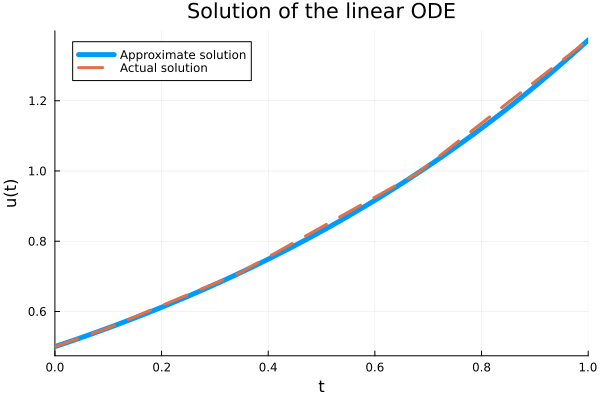

In [12]:
plot(sol, linewidth=5, title="Solution of the linear ODE", xaxis="t", yaxis="u(t)", label="Approximate solution")
plot!(sol.t, t -> u0 * exp(alpha * t), lw=3, ls=:dash, label="Actual solution")

In [13]:
sol.t

5-element Vector{Float64}:
 0.0
 0.09964258706516003
 0.3457024247583422
 0.6776921908052249
 1.0

In [14]:
sol.u

5-element Vector{Float64}:
 0.5
 0.552938681151017
 0.7089376245893467
 0.9913594502399238
 1.3728004409033037

In [15]:
# value of solution at e.g. 0.2
sol(0.2)

0.6119240245530987

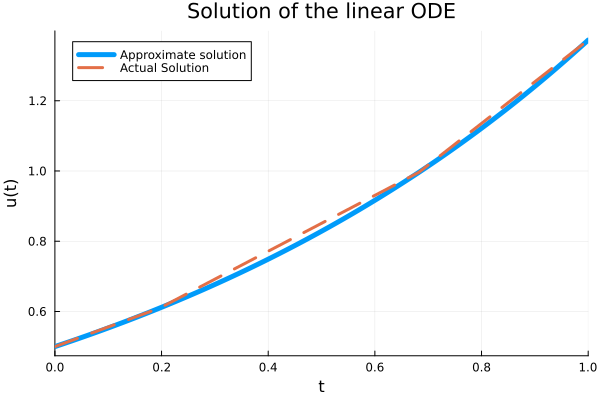

In [16]:
# lower accuracy
sol2 = solve(prob, reltol=1e-2, abstol=1e-2)
plot(sol2, linewidth=5, title="Solution of the linear ODE", xaxis="t", yaxis="u(t)", label="Approximate solution")
plot!(sol2.t, t -> 0.5 * exp(alpha * t), lw=3, ls=:dash, label="Actual Solution")

In [17]:
sol2.u

4-element Vector{Float64}:
 0.5
 0.6098575462845294
 0.9963939687220439
 1.3727997725845866

Now only 4 element vector, not 5.

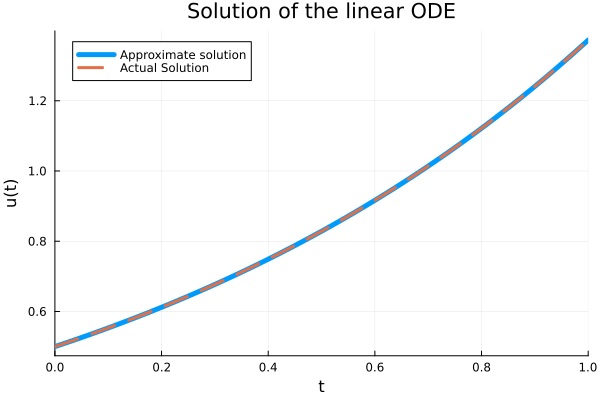

In [18]:
# higher accuracy
sol3 = solve(prob, reltol=1e-14, abstol=1e-14);
plot(sol3, linewidth=5, title="Solution of the linear ODE", xaxis="t", yaxis="u(t)", label="Approximate solution")
plot!(sol3.t, t -> 0.5 * exp(alpha * t), lw=3, ls=:dash, label="Actual Solution")

In [19]:
sol3.u

33-element Vector{Float64}:
 0.5
 0.5030607544114138
 0.5084858222619822
 0.5170823072395272
 0.5278251325087624
 0.5401371317855586
 0.5542892368251977
 0.5700103856039416
 0.5873636775526352
 0.6061628060483898
 0.6264087661277773
 0.6480244477649643
 0.6709751457947637
 ⋮
 0.9340638260454618
 0.9696319401994442
 1.0065390078427732
 1.0448220087387348
 1.0845080812631074
 1.1256519451420628
 1.1682721153746913
 1.2124341092083537
 1.2581711352647809
 1.3055472436743087
 1.3545949480300603
 1.372800507508458

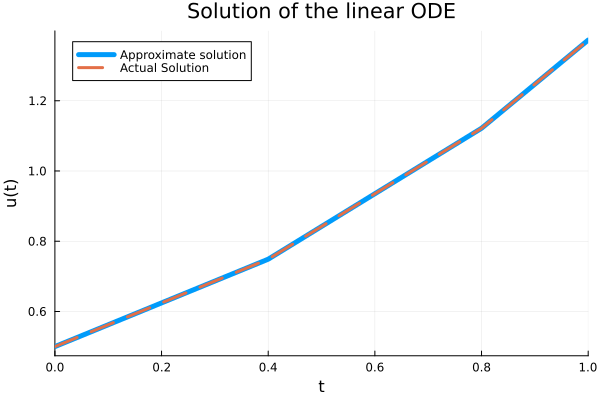

In [20]:
# saveat parameter: save at intermediate step
sol_saveat = solve(prob, reltol=1e-2, abstol=1e-2, saveat=0.4)
plot(sol_saveat, linewidth=5, title="Solution of the linear ODE", xaxis="t", yaxis="u(t)", label="Approximate solution")
plot!(sol_saveat.t, t -> 0.5 * exp(alpha * t), lw=3, ls=:dash, label="Actual Solution")

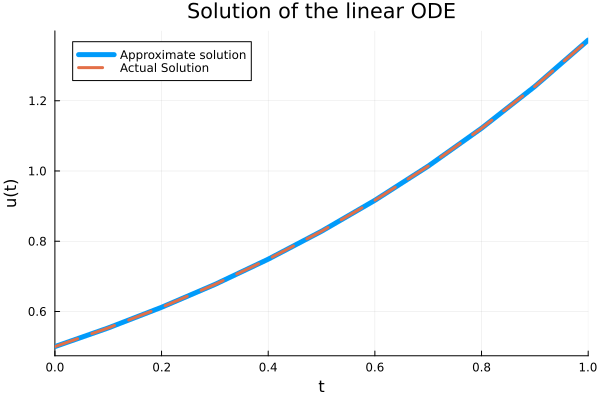

In [21]:
# saveat parameter
sol_saveat = solve(prob, reltol=1e-2, abstol=1e-2, saveat=0.1)
plot(sol_saveat, linewidth=5, title="Solution of the linear ODE", xaxis="t", yaxis="u(t)", label="Approximate solution")
plot!(sol_saveat.t, t -> 0.5 * exp(alpha * t), lw=3, ls=:dash, label="Actual Solution")

## Predefined problems from DiffEqProblemLibrary.jl

In [22]:
# Load example linear problem from ODEProblemLibrary
# Not doing here because we want to define them ourselves!

# using DiffEqProblemLibrary.ODEProblemLibrary
# prob = ODEProblemLibrary.prob_ode_linear

### System of equations (Van der Pol equations)
$$\frac{dx}{dt} = y$$
$$\frac{dy}{dt} = \mu ((1-x^2)y-x)$$
with $\mu = 1.0$ and $u_0 = [0, \sqrt{3}]$

In [24]:
# Could just do:
# load problem ODEProblemLibrary

# prob_ode_vanderpol = ODEProblemLibrary.prob_ode_vanderpol
# sol = solve(prob_ode_vanderpol)
# plot(sol, linewidth = 5, title = "Solution of the Solution of the Van der Pol Equations", xaxis = "t", yaxis = "u(t)", label = "Approximate solution")

In [30]:
μ = 10^6
# x = u[1], y = u[2]
# dx/dt = du[1], dy/dt = du[2]
function van!(du, u, p, t)
    du[1] = μ * ((1 - u[1]^2) * u[2] - u[1])
    du[2] = u[2]
end

van! (generic function with 1 method)

In [31]:
u0 = [0; sqrt(3)]
tspan = (0.0, 1.0)
prob_ode_vanderpol = ODEProblem(van!, u0, tspan)
sol = solve(prob_ode_vanderpol)
sol.u

54-element Vector{Vector{Float64}}:
 [0.0, 1.7320508075688772]
 [0.000999134363957248, 1.7320508085683002]
 [0.010958397076572982, 1.73205081856253]
 [0.0725443996964946, 1.7320508818124083]
 [0.2005038109249363, 1.7320510239780342]
 [0.36758056090290175, 1.7320512470758]
 [0.5200031888172162, 1.7320515308620494]
 [0.6196425900326429, 1.7320518254238235]
 [0.6864172051752879, 1.7320521783539082]
 [0.7226509150086028, 1.73205257178035]
 [0.740761192059053, 1.7320530331625206]
 [0.7483860935154016, 1.732053566716141]
 [0.7511476239755946, 1.7320542026429961]
 ⋮
 [0.7995373541029991, 2.2157677587125697]
 [0.8085381903517199, 2.334240002694655]
 [0.8178962786643117, 2.4696700400484026]
 [0.8274670061638307, 2.6232008738863413]
 [0.8371558378929299, 2.7968153318481184]
 [0.8468516499287303, 2.9923470114278845]
 [0.8564859827923647, 3.2125916577993796]
 [0.8659794602320253, 3.4603714562096877]
 [0.8752861288633738, 3.7396569389748326]
 [0.8843519480053978, 4.054698781581105]
 [0.893147711581

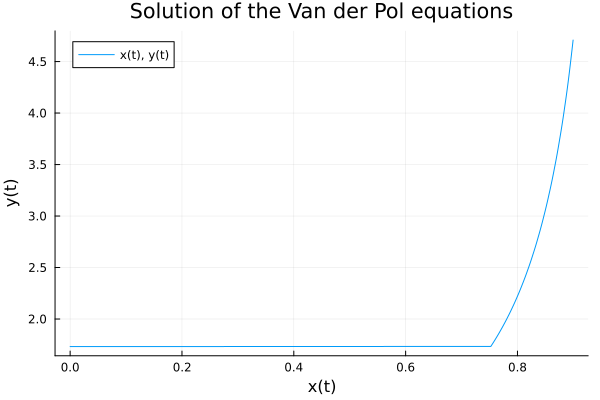

In [32]:
# 2d phase space plot
plot(sol, idxs=(1, 2), title="Solution of the Van der Pol equations", linewidth=1, label="x(t), y(t)", xaxis="x(t)", yaxis="y(t)")

Plots.AnimatedGif("/home/jon/code/julia-learning/3b_solving_optimisation_problems/vanderpol.gif")
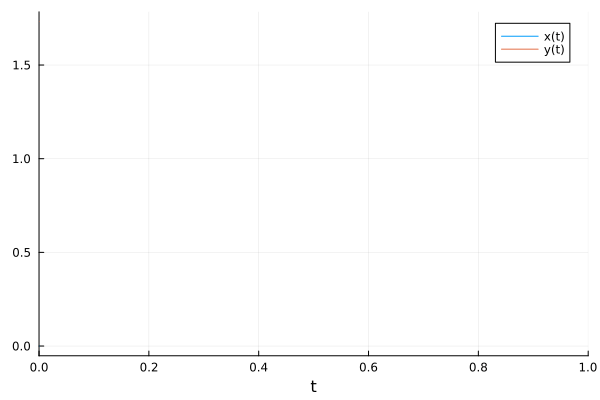

In [33]:
animate(sol, every=2, fps=10, label=["x(t)" "y(t)"], "vanderpol.gif")

## System of equations (Lorenz equations)
$$\frac{dx}{dt} = \sigma (y-x)$$
$$\frac{dy}{dt} = x(\rho - z) - y$$
$$\frac{dz}{dt} = xy - \beta z$$

In [34]:
# in-place function again
function lorenz!(du, u, p, t)
    # p and t aren't used!
    du[1] = 10.0 * (u[2] - u[1])
    du[2] = u[1] * (28.0 - u[3]) - u[2]
    du[3] = u[1] * u[2] - (8 / 3) * u[3]
end

lorenz! (generic function with 1 method)

In [35]:
u0 = [1.0; 0.0; 0.0]
tspan = (0.0, 100.0)
prob = ODEProblem(lorenz!, u0, tspan)
sol = solve(prob)
sol.u

1281-element Vector{Vector{Float64}}:
 [1.0, 0.0, 0.0]
 [0.9996434557625105, 0.0009988049817849058, 1.781434788799189e-8]
 [0.9961045497425811, 0.010965399721242457, 2.1469553658389193e-6]
 [0.9693591550149778, 0.08977063252764937, 0.0001438019170127846]
 [0.924204355043198, 0.242289149116772, 0.0010461625397616113]
 [0.8800455796215916, 0.4387364900041282, 0.0034242599668253874]
 [0.8483309836977301, 0.6915629475762161, 0.008487624968655677]
 [0.8495036679850485, 1.0145426495980538, 0.018212090123888365]
 [0.9139069520070257, 1.4425599557988966, 0.03669382071284047]
 [1.0888638157267199, 2.052326562845511, 0.07402573450924263]
 [1.4608626762755585, 3.0206719763684764, 0.160039355072216]
 [2.162723385463873, 4.6333636144497445, 0.3771173678677311]
 [3.3684642325435363, 7.267693727122867, 0.9363555414291395]
 ⋮
 [2.4154751319743304, 0.9019051839955854, 23.10904521543824]
 [1.9010431518181314, 2.075631191607503, 18.469762607052317]
 [2.3313747500610864, 3.427114121484939, 15.773720459660

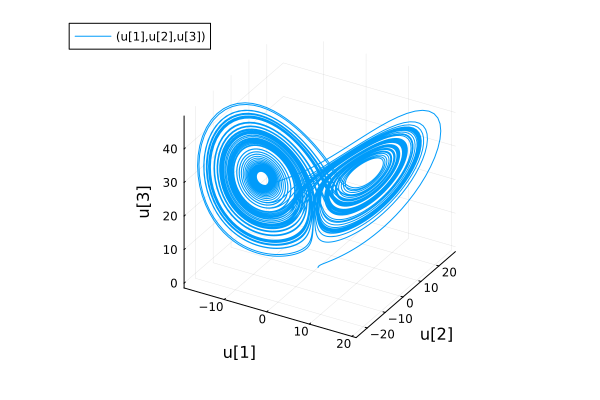

In [36]:
# 3d phase-space plot
plot(sol, idxs=(1, 2, 3))

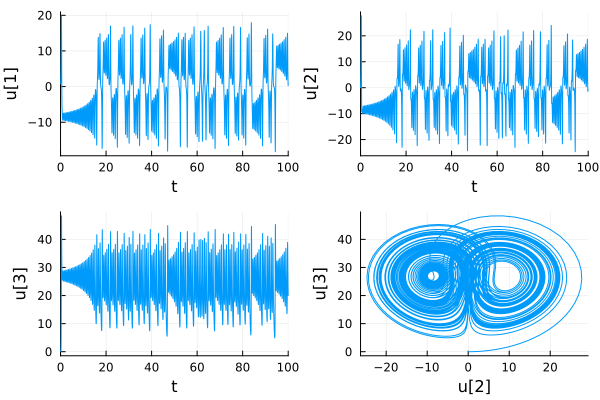

In [37]:
# first component only
p1 = plot(sol, idxs=(0, 1))
# second component only
p2 = plot(sol, idxs=(0, 2))
# third component only
p3 = plot(sol, idxs=(0, 3))
# second and third component
p4 = plot(sol, idxs=(2, 3))
plot(p1, p2, p3, p4, layout=(2, 2), legend=false)

## Defining parameterised functions

3-element Vector{Float64}:
 0.5
 0.5012580251693002
 0.5050250835420841

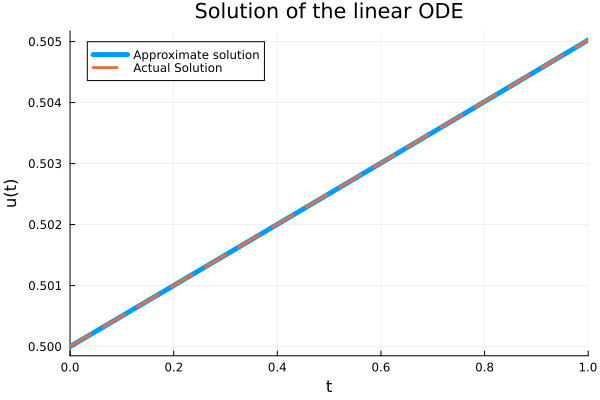

In [38]:
# ODEProblemLibrary.prob_ode_linear with parameter
alpha = 0.01
g(u, p, t) = p * u;
u0 = 1 / 2;
tspan = (0.0, 1.0);
prob = ODEProblem(f, u0, tspan, alpha);
sol = solve(prob);
display(sol.u)
plot(sol, linewidth=5, title="Solution of the linear ODE", xaxis="t", yaxis="u(t)", label="Approximate solution")
plot!(sol.t, t -> 0.5 * exp(alpha * t), lw=3, ls=:dash, label="Actual Solution")

8-element Vector{Float64}:
 0.5
 0.5946443932638155
 0.8000127328680215
 1.1431179345486775
 1.7808840584593943
 2.9793956876426617
 5.3716320884868365
 6.0912289969678435

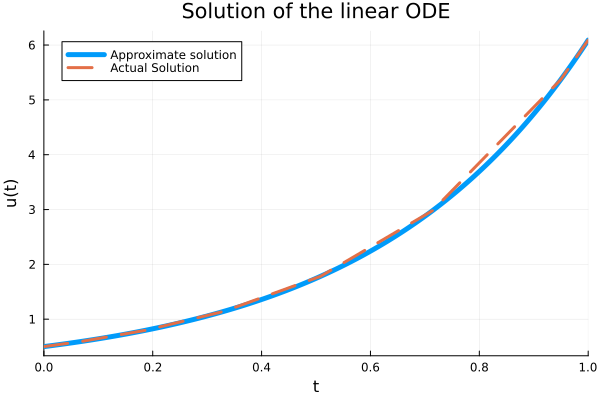

In [39]:
alpha = 2.5
sol = solve(prob);
display(sol.u)
plot(sol, linewidth=5, title="Solution of the linear ODE", xaxis="t", yaxis="u(t)", label="Approximate solution")
plot!(sol.t, t -> 0.5 * exp(alpha * t), lw=3, ls=:dash, label="Actual Solution")

In [41]:
# lorenz with parameter
function parameterized_lorenz!(du, u, p, t)
    du[1] = p[1] * (u[2] - u[1])
    du[2] = u[1] * (p[2] - u[3]) - u[2]
    du[3] = u[1] * u[2] - p[3] * u[3]
end

u0 = [1.0, 0.0, 0.0]
tspan = (0.0, 1.0)
p = [10.0, 28.0, 8 / 3]
prob = ODEProblem(parameterized_lorenz!, u0, tspan, p)

ODEProblem with uType Vector{Float64} and tType Float64. In-place: true
timespan: (0.0, 1.0)
u0: 3-element Vector{Float64}:
 1.0
 0.0
 0.0

In [44]:
# nicer version
function parameterized_lorenz_2!(du, u, p, t)
    x, y, z = u
    σ, ρ, β = p
    du[1] = dx = σ * (y - x)
    du[2] = dy = x * (ρ - z) - y
    du[3] = dz = x * y - β * z
end

u0 = [1.0, 0.0, 0.0]
tspan = (0.0, 1.0)
p = [10.0, 28.0, 8 / 3]
prob = ODEProblem(parameterized_lorenz_2!, u0, tspan, p)

sol = solve(prob)

retcode: Success
Interpolation: specialized 4th order "free" interpolation, specialized 2nd order "free" stiffness-aware interpolation
t: 28-element Vector{Float64}:
 0.0
 3.5678604836301404e-5
 0.0003924646531993154
 0.0032624087100077666
 0.009058076582749423
 0.016956470605311864
 0.027689959227781235
 0.04185635103821218
 0.060240410627700816
 0.0836854113984534
 0.11336499269451543
 0.14862181409827
 0.18703978025370946
 ⋮
 0.37221158152511746
 0.4201373199451134
 0.4637204183034679
 0.504946073924883
 0.5570623245742057
 0.6068388057939043
 0.669020447362476
 0.7276641343167435
 0.7988542865022868
 0.8763208592325533
 0.9661629617040817
 1.0
u: 28-element Vector{Vector{Float64}}:
 [1.0, 0.0, 0.0]
 [0.9996434557625105, 0.0009988049817849058, 1.781434788799189e-8]
 [0.9961045497425811, 0.010965399721242457, 2.1469553658389193e-6]
 [0.9693591550149778, 0.08977063252764937, 0.0001438019170127846]
 [0.924204355043198, 0.242289149116772, 0.0010461625397616113]
 [0.8800455796215916, 0.4